# Zomato Data Analysis Project

In [285]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [286]:
df = pd.read_csv("zomato_dataset.csv")
print(df)

              Restaurant Name  Dining Rating  Delivery Rating  Dining Votes  \
0                  Doner King            3.9              4.2            39   
1                  Doner King            3.9              4.2            39   
2                  Doner King            3.9              4.2            39   
3                  Doner King            3.9              4.2            39   
4                  Doner King            3.9              4.2            39   
...                       ...            ...              ...           ...   
123652  Ariena Boutique Hotel            3.9              4.2            13   
123653  Ariena Boutique Hotel            3.9              4.2            13   
123654  Ariena Boutique Hotel            3.9              4.2            13   
123655  Ariena Boutique Hotel            3.9              4.2            13   
123656  Ariena Boutique Hotel            3.9              4.2            13   

        Delivery Votes   Cuisine  Place Name       

In [287]:
print("Rows and Columns:", df.shape)
print("\nColumns:", df.columns)

Rows and Columns: (123657, 12)

Columns: Index(['Restaurant Name', 'Dining Rating', 'Delivery Rating', 'Dining Votes',
       'Delivery Votes', 'Cuisine ', 'Place Name', 'City', 'Item Name',
       'Best Seller', 'Votes', 'Prices'],
      dtype='str')


In [288]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['Restaurant Name', 'Dining Rating', 'Delivery Rating', 'Dining Votes',
       'Delivery Votes', 'Cuisine', 'Place Name', 'City', 'Item Name',
       'Best Seller', 'Votes', 'Prices'],
      dtype='str')


In [289]:
df["Prices"] = pd.to_numeric(df["Prices"], errors="coerce")
df["Votes"] = pd.to_numeric(df["Votes"], errors="coerce")
df["Dining Rating"] = pd.to_numeric(df["Dining Rating"], errors="coerce")

In [290]:
print(df.isnull().sum())

Restaurant Name        0
Dining Rating      32236
Delivery Rating     1280
Dining Votes           0
Delivery Votes         0
Cuisine                0
Place Name             0
City                   0
Item Name              0
Best Seller        95715
Votes                  0
Prices                 0
dtype: int64


In [291]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 22127


In [292]:
df.drop_duplicates(inplace=True)

1. Which Cuisine has the highest number of menu items ?

In [293]:
cuisine_count = df["Cuisine"].value_counts().head(10)
print(cuisine_count)

Cuisine
Beverages       32818
Pizza           12383
Desserts         9285
Fast Food        9268
Chinese          5066
Sichuan          4812
Biryani          3462
Shake            2784
North Indian     2436
Street Food      2371
Name: count, dtype: int64


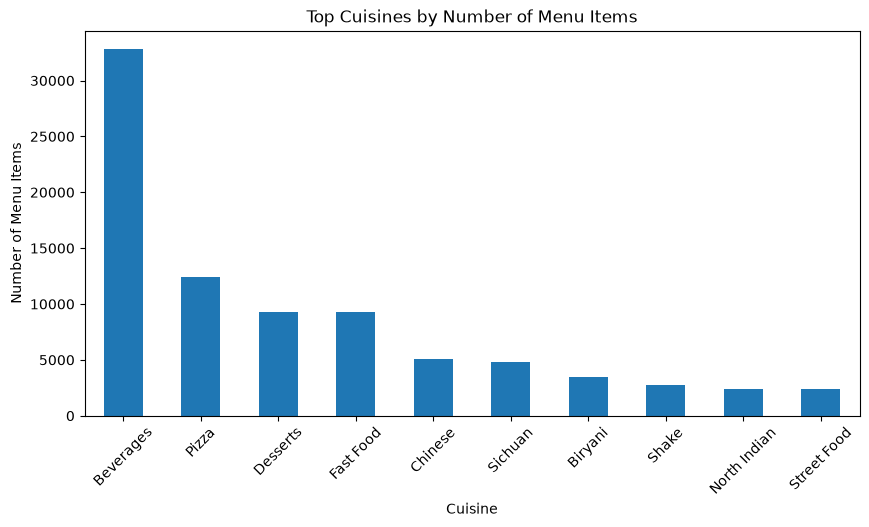

In [294]:
plt.figure(figsize=(10,5))
cuisine_count.plot(kind="bar")
plt.title("Top Cuisines by Number of Menu Items")
plt.xlabel("Cuisine")
plt.ylabel("Number of Menu Items")
plt.xticks(rotation=45)
plt.show()

2. Which are the top 10 restaurants with the most menu items?

In [295]:
top_restaurants = df["Restaurant Name"].value_counts().head(10)
print(top_restaurants)

Restaurant Name
McDonald's           1526
FreshMenu            1022
Burger King          1006
Pizza Hut             888
Domino's Pizza        757
La Pino'z Pizza       728
The Momoz Hub         672
Subway                653
Savoury Sea Shell     568
Raj Restaurant        525
Name: count, dtype: int64


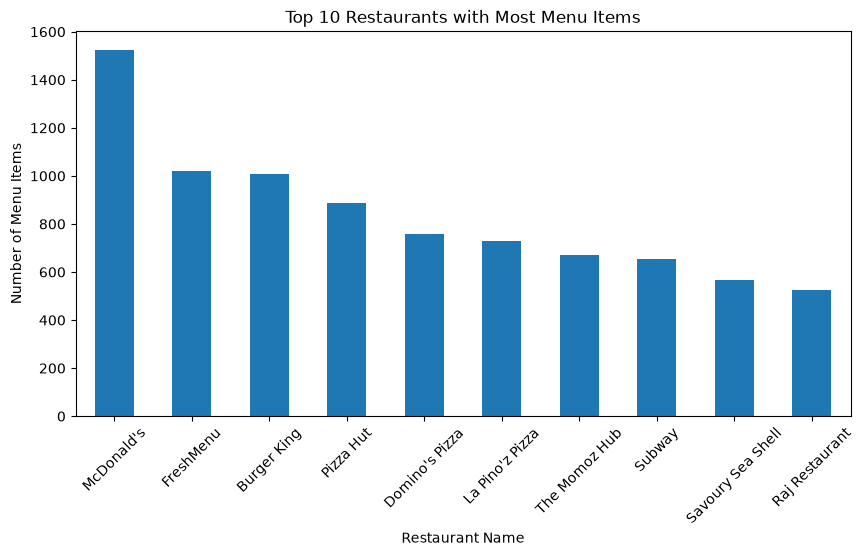

In [296]:
plt.figure(figsize=(10,5))
top_restaurants.plot(kind="bar")
plt.title("Top 10 Restaurants with Most Menu Items")
plt.xlabel("Restaurant Name")
plt.ylabel("Number of Menu Items")
plt.xticks(rotation=45)
plt.show()

3.What is the distribution of menu item prices?

In [297]:
print("Maximum price:", df["Prices"].max())
print("Minimum price:", df["Prices"].min())
print("Average price:", df["Prices"].mean())

Maximum price: 12024.0
Minimum price: 0.95
Average price: 243.69075790406774


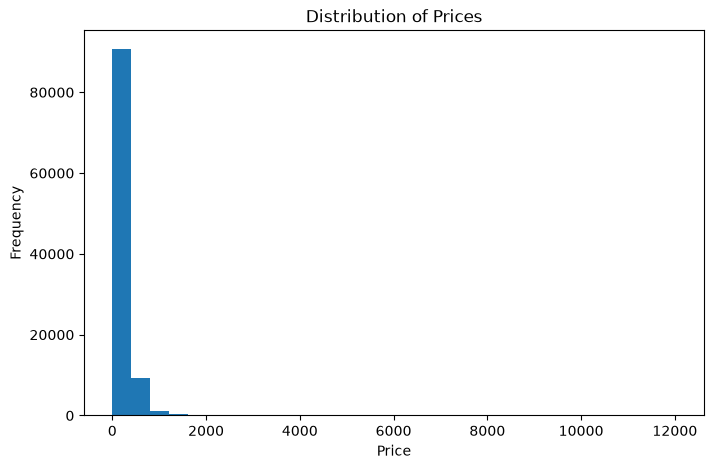

In [298]:
plt.figure(figsize=(8,5))
plt.hist(df["Prices"].dropna(), bins=30)
plt.title("Distribution of Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

4.Which are the top 10 menu items with the highest votes?

In [299]:
top_items_votes = df.groupby("Item Name")["Votes"].sum().sort_values(ascending=False).head(10)
print(top_items_votes)

Item Name
Chicken Biryani            69919
Mutton Biryani             26647
Rumali Roti                20443
Mini Chicken Biryani       16914
Chicken Fried Rice         14187
Chicken 65                 13366
Tandoori Chicken           11787
Special Chicken Biryani    10710
Beef Biryani               10287
Chicken Biryani Single     10134
Name: Votes, dtype: int64


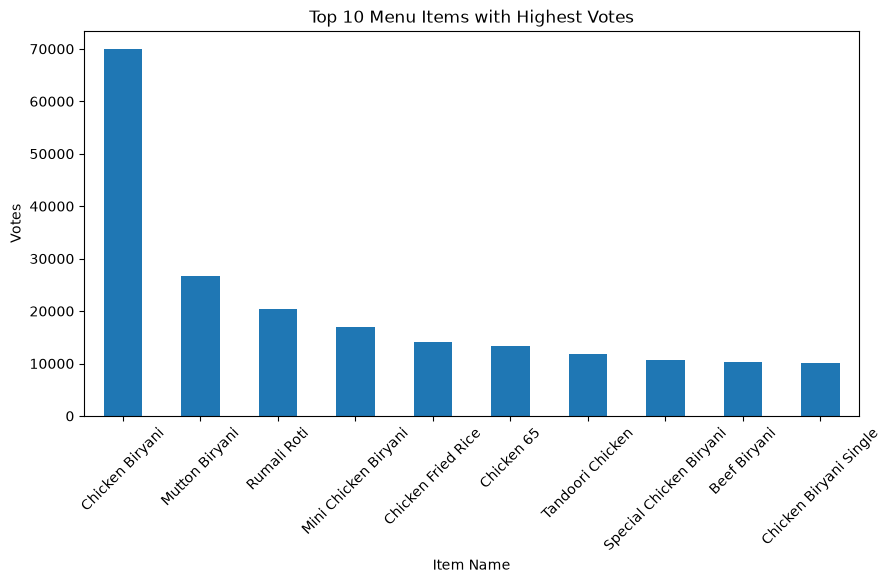

In [300]:
plt.figure(figsize=(10,5))
top_items_votes.plot(kind="bar")
plt.title("Top 10 Menu Items with Highest Votes")
plt.xlabel("Item Name")
plt.ylabel("Votes")
plt.xticks(rotation=45)
plt.show()

6. How many restaurants are present in each city?

In [301]:
city_restaurants = df.groupby("City")["Restaurant Name"].nunique().sort_values(ascending=False)
print(city_restaurants)

City
Hyderabad       129
Jaipur           92
Chennai          87
Bangalore        81
Mumbai           80
Ahmedabad        74
Kochi            72
Kolkata          64
Pune             60
Lucknow          57
Raipur           52
Goa              31
New Delhi        24
Banaswadi         1
Magrath Road      1
Malleshwaram      1
Ulsoor            1
Name: Restaurant Name, dtype: int64


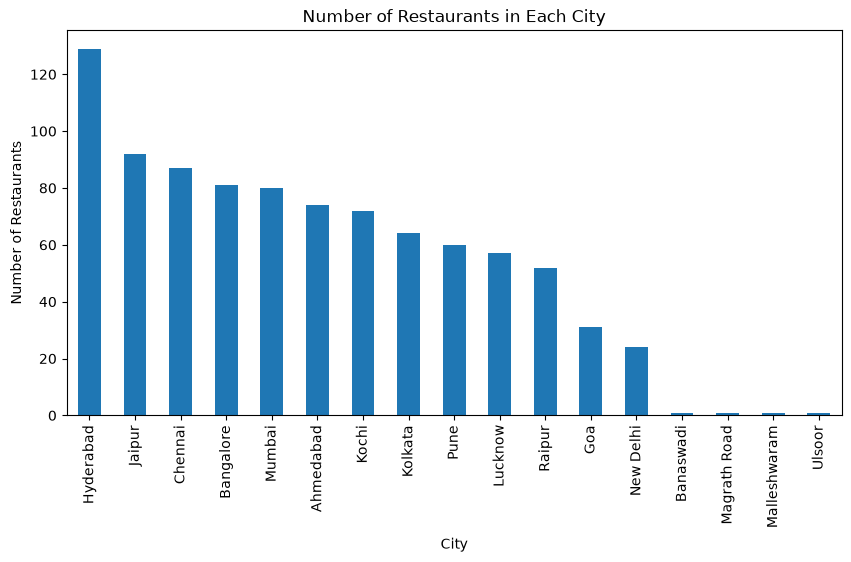

In [302]:
plt.figure(figsize=(10,5))
city_restaurants.plot(kind="bar")
plt.title("Number of Restaurants in Each City")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=90)
plt.show()

7. What is the average dining rating for each city?

In [303]:
city_rating = df.groupby("City")["Dining Rating"].mean().sort_values(ascending=False)
print(city_rating)

City
Goa             4.052224
Malleshwaram    4.000000
New Delhi       3.974378
Hyderabad       3.897264
Lucknow         3.873163
Raipur          3.857374
Mumbai          3.846776
Kochi           3.827541
Kolkata         3.825061
Chennai         3.823576
Ahmedabad       3.778595
Jaipur          3.769591
Pune            3.736595
Bangalore       3.716464
Banaswadi       3.700000
Magrath Road    3.500000
Ulsoor               NaN
Name: Dining Rating, dtype: float64


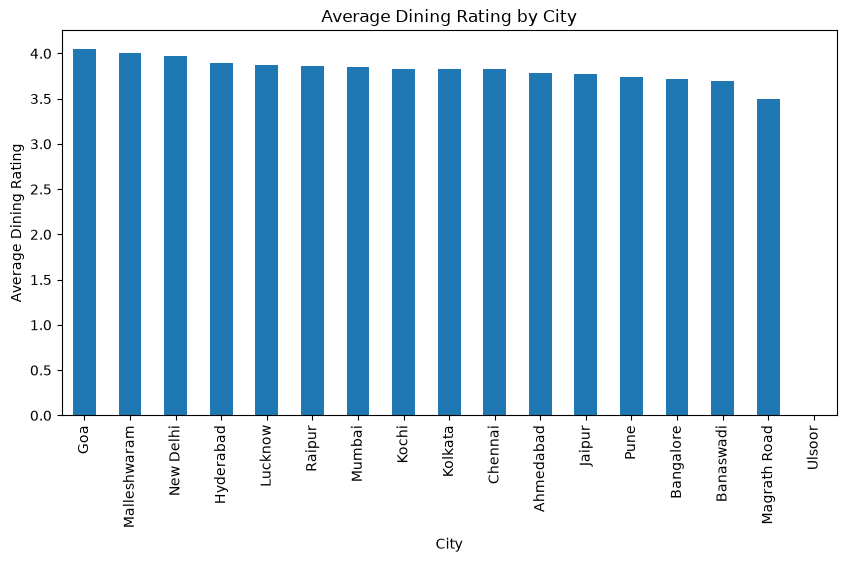

In [304]:
plt.figure(figsize=(10,5))
city_rating.plot(kind="bar")
plt.title("Average Dining Rating by City")
plt.xlabel("City")
plt.ylabel("Average Dining Rating")
plt.xticks(rotation=90)
plt.show()

8. How many menu items are available in each cuisine?

In [305]:
cuisine_items = df["Cuisine"].value_counts().head(10)
print(cuisine_items)

Cuisine
Beverages       32818
Pizza           12383
Desserts         9285
Fast Food        9268
Chinese          5066
Sichuan          4812
Biryani          3462
Shake            2784
North Indian     2436
Street Food      2371
Name: count, dtype: int64


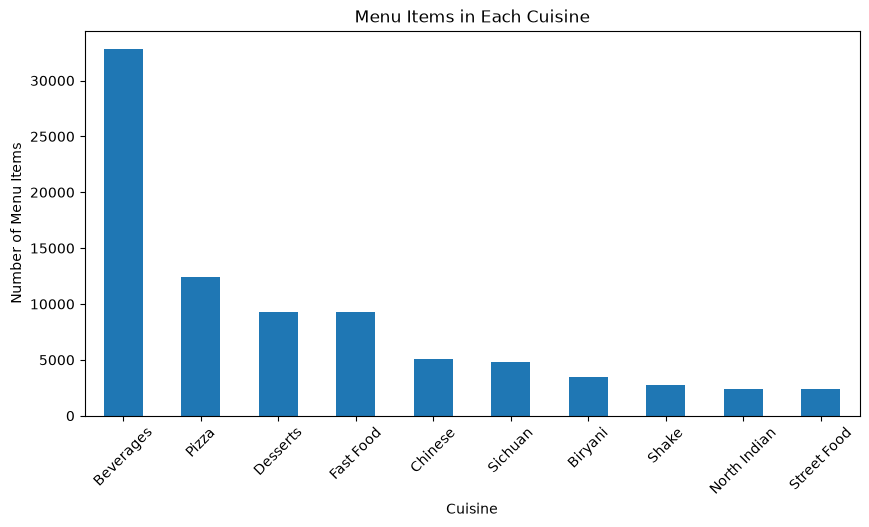

In [306]:
plt.figure(figsize=(10,5))
cuisine_items.plot(kind="bar")
plt.title("Menu Items in Each Cuisine")
plt.xlabel("Cuisine")
plt.ylabel("Number of Menu Items")
plt.xticks(rotation=45)
plt.show()

10. What is the distribution of dining ratings?

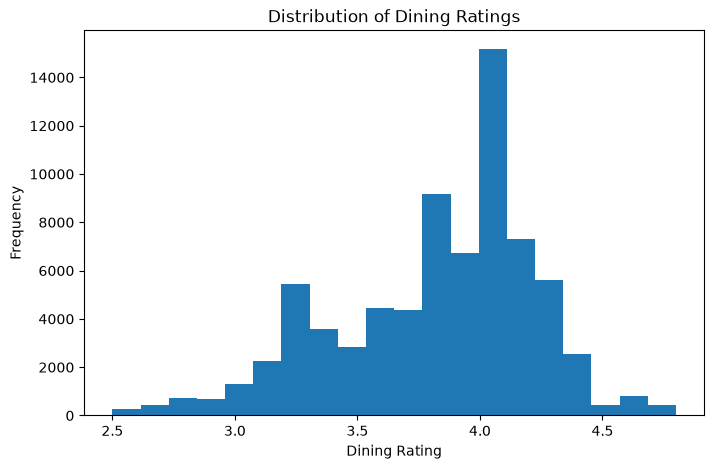

In [307]:
plt.figure(figsize=(8,5))
plt.hist(df["Dining Rating"].dropna(), bins=20)
plt.title("Distribution of Dining Ratings")
plt.xlabel("Dining Rating")
plt.ylabel("Frequency")
plt.show()